

<h2><center>  </center></h2>

<h1><center> Dirigido por: Geól. Gabriel Moreno, PhD Paul Goyes </center></h1>

<h1><center>Curso de procesamiento de anomalías gravimétricas con Python </center></h1>

<h2><center>  </center></h2>


<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEj2l9vBVWOQruAuZlRNNUpLY-TEBaIyuUtWDfwZ1yW4gnZti88Orar5vSzxAYWPlceoJAX70UgJ1fuvte8XENG7NQsWdOJ_EGlUfYIo9aZHaOOZpifHTZCoCmYxItUJXOZQzbjmK86BYwU7wT6v29go5ioHW6cDVxYMb6ROq1xqzFOfZNumFqVG9t9d3bKf
" width="90%" style="max-width: 1000px;">
</div>

<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEhAeFmg8PN30xIEAJSmdGo2_7SpnOgI0fvfQhjMBFaJR85yYq7eKxYIvCFjC0C5BW_Vwxbu0UXK-vNF9cfHxQAWBn-TYch6cbvs_0LUlMwU9KlEloVUCihgChqwBdgtb1of7czn1LOhBHIaPdFBHTIoCBd0037Y8mv71IdWWUBSpMQyQsCTLGiln1o1dSmr" width="90%" style="max-width: 1000px;">
</div>





<h2><center>Datos: Beltrán, M.A. (2020). Gravimetría y magnetometría del área Geotérmica del Volcán Cerro Machín. Bogotá: Servicio Geológico Colombiano </center></h2>


<h2><center> 136 datos tomados en una campaña del SGC de gravimetría y magnetometría en el año 2022, en el Área Geotérmica del Cerro Machín
</center></h2>

<h2><center>
 Los datos están estan procesados y están acomapañados de un informe de procesamiento e intepretación, junto a un proyecto de Oasis Montaj (Software usado para hacer el procesamiento)
</center></h2>



<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEibJTS-ffymdntR56SK9OylRllfuvQ2pMTXBMnUiY2X6YuZ4QCwv5ZrSbw5FjmNoyKgtkOCUVn_pY8SuGR7f-SpbyOw8ed57_MNI7cUYgp8Mx8nDxERwZaCs75NJiHn8JDw8RF9cCPgohwfsafrBGl87O6FYKxtt01yRf-LaP8ZGotvzQZbYiA5M0DwcC5J
" width="1000%" style="max-width: 10000px;">
</div>

In [ ]:
!pip install rioxarray ensaio harmonica geopandas


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import rioxarray as rioxr
import xarray as xr
from pyproj import CRS, Transformer
import ensaio
import harmonica as hm
from scipy.interpolate import griddata
import geopandas as gpd
import verde as vd
import os

from scipy.interpolate import griddata
from scipy.interpolate import RBFInterpolator


from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error


### Cargar los datos tomados del campo gravitacional en la zona de estudio

In [ ]:
# Nombre del archivo
filename = 'Datos_Gravimetria_AGCM.csv'

In [ ]:
# Leer el archivo CSV
df = pd.read_csv(filename, sep=';')

df

,Station,Long,Lat,X,Y,Z,G_Obs,Mask
0,93,-75.4080,4.4427,4732883.463,2049345.170,1802.569,977628.5013,18.5238
1,98,-75.3415,4.4585,4740260.711,2051069.569,2014.366,977621.7091,14.8273
2,1000,-75.4053,4.5156,4733205.458,2057405.449,2127.088,977552.7659,17.8755
3,1001,-75.4063,4.5073,4733091.517,2056492.891,1954.450,977583.5755,25.0323
4,1002,-75.4071,4.5116,4733001.529,2056965.559,1981.408,977578.0543,23.3035
...,...,...,...,...,...,...,...,...
131,3023,-75.3437,4.4639,4740019.008,2051673.049,2339.895,977519.8658,17.0514
132,3024,-75.3415,4.4585,4740260.711,2051069.569,2014.666,977585.9545,14.8246
133,3025,-75.3457,4.4563,4739795.423,2050836.891,2008.001,977588.4678,13.8327
134,73124018,-75.4172,4.4422,4731859.783,2049294.485,1832.207,977623.5576,19.2228


<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEhmAVs8TdMHQwavUehj-L3wfAxEp7i9uve25YURkXLEpND3P60hmQFLjBHnwcv_wiXt9R1ZwsfohmgrtFVsl2_B6_z3r_7nwkFvA685BRsf3nMybZXwmeXmuYnxAwQ8UHjG4LdPkz1_dy0ccKn0sOlBj5B4BtW5Y5ULKupU1Lo1W58dcgsuuZsk1Y3N961b" width="90%" style="max-width: 1000px;">
</div>

<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEi-3fRpdDt0lWFgA1ynJOzt2oM30oJfLzjGDj_hor2ulkPQ_xOIKzBMJqxQOASBkMSd7XA9NGlGneIpaTymoXHDZTWrluDZeLkIB5octCCHHQZ6X0awAteFi7ZTJS2k4j5GbSUjlBWXOFXKXj4JHDMD3j67-xjZvNP43_CuG_tZUXrWmBS2FB2e-uiKKsfU" width="90%" style="max-width: 1000px;">
</div>

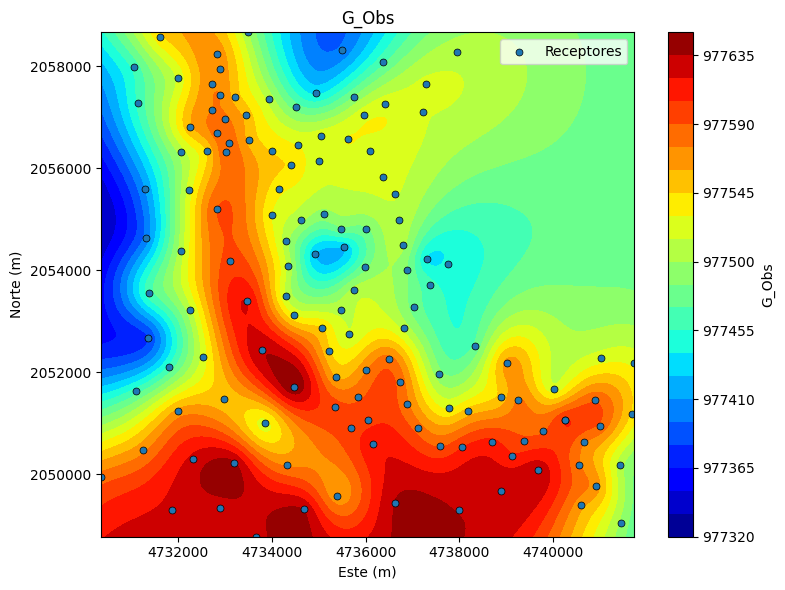

In [ ]:
from scipy.interpolate import griddata
from scipy.interpolate import RBFInterpolator

data = df[['X', 'Y', 'G_Obs']].dropna()

X = data['X'].to_numpy()
Y = data['Y'].to_numpy()
XY = data[['X', 'Y']].to_numpy()
G_Obs = data['G_Obs'].to_numpy()

#malla
nx, ny = 300, 300
xi = np.linspace(XY[:, 0].min(), XY[:, 0].max(), nx)
yi = np.linspace(XY[:, 1].min(), XY[:, 1].max(), ny)
Xi, Yi = np.meshgrid(xi, yi)
xg = np.column_stack([Xi.ravel(), Yi.ravel()])

rbf = RBFInterpolator(XY, G_Obs, kernel="thin_plate_spline", smoothing=1.0)
Z = rbf(xg).reshape(ny, nx)

plt.figure(figsize=(8,6))
im = plt.contourf(Xi, Yi, Z, levels=30, cmap='jet')


plt.ticklabel_format(style='plain', axis='both')

plt.colorbar(im, label='G_Obs')
plt.scatter(df['X'], df['Y'], s=25, edgecolor='k', linewidth=0.5, label='Receptores')
plt.xlabel('Este (m)'); plt.ylabel('Norte (m)')


plt.title('G_Obs')
plt.legend()
plt.tight_layout()
plt.savefig('G_Obs_contour.svg', dpi=300)
plt.show()






<img src="https://blogger.googleusercontent.com/img/a/AVvXsEibJTS-ffymdntR56SK9OylRllfuvQ2pMTXBMnUiY2X6YuZ4QCwv5ZrSbw5FjmNoyKgtkOCUVn_pY8SuGR7f-SpbyOw8ed57_MNI7cUYgp8Mx8nDxERwZaCs75NJiHn8JDw8RF9cCPgohwfsafrBGl87O6FYKxtt01yRf-LaP8ZGotvzQZbYiA5M0DwcC5J
" width="80%" style="max-width: 10000px;">


<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEiNkuUtPTRuv2Qiw7V3UF5n1oxK0KNwrJZmTreKuFrOWZWLg0O_3mYIb1RG2d8dncjvWuBwC272hf7wHvw2IwtY9ofD9yUZbfTqQMJVzXhsFqtORb82pMFvJUd1hdf9SAaI62NRmPJf6k0m649iTkgkDwq21i6BpchsywmRQ8YWE2gM5Mrhl79E0huMyVVe" width="90%" style="max-width: 1000px;">
</div>

### Calcular la gravedad teórica según el elipsode GRS80 promedio en el área de estudio

In [ ]:
df['GRS1980_(gt)'] = 978032.7 * (1 + 0.0053024*np.sin(np.deg2rad(df['Lat']))**2 - 0.0000058*np.sin(2*np.deg2rad(df['Lat']))**2
)

df

,Station,Long,Lat,X,Y,Z,G_Obs,Mask,GRS1980_(gt)
0,93,-75.4080,4.4427,4732883.463,2049345.170,1802.569,977628.5013,18.5238,978063.682117
1,98,-75.3415,4.4585,4740260.711,2051069.569,2014.366,977621.7091,14.8273,978063.902439
2,1000,-75.4053,4.5156,4733205.458,2057405.449,2127.088,977552.7659,17.8755,978064.705131
3,1001,-75.4063,4.5073,4733091.517,2056492.891,1954.450,977583.5755,25.0323,978064.587823
4,1002,-75.4071,4.5116,4733001.529,2056965.559,1981.408,977578.0543,23.3035,978064.648571
...,...,...,...,...,...,...,...,...,...
131,3023,-75.3437,4.4639,4740019.008,2051673.049,2339.895,977519.8658,17.0514,978063.977916
132,3024,-75.3415,4.4585,4740260.711,2051069.569,2014.666,977585.9545,14.8246,978063.902439
133,3025,-75.3457,4.4563,4739795.423,2050836.891,2008.001,977588.4678,13.8327,978063.871714
134,73124018,-75.4172,4.4422,4731859.783,2049294.485,1832.207,977623.5576,19.2228,978063.675158


<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEjlJwS5br7ifz7hGq-laRhy7fRLvpWAwXAGnv6-tg6k6TqQp05ti3-oG523g4xTXYh1MLOkoPAbgUrj6EGL1XHz6sVNoijtWvAbRbkPdSwAN-EOCG6TRuxwszWoACif5V_gjPDAn0uARC6XA286MM_2lt07P3V246PQ6EwsbjDAz9yQQFENINyZf0vwFwsv" width="90%" style="max-width: 1000px;">
</div>



### Corrección de aire libre

In [ ]:
# Definir la función de corrección por aire libre
def correccion_aire_libre(Z, Z0=0):
    return -0.3086 * (Z - Z0)

# Aplicar la función a la columna Z
df['CA'] = correccion_aire_libre(df['Z'])


df

,Station,Long,Lat,X,Y,Z,G_Obs,Mask,GRS1980_(gt),CA
0,93,-75.4080,4.4427,4732883.463,2049345.170,1802.569,977628.5013,18.5238,978063.682117,-556.272793
1,98,-75.3415,4.4585,4740260.711,2051069.569,2014.366,977621.7091,14.8273,978063.902439,-621.633348
2,1000,-75.4053,4.5156,4733205.458,2057405.449,2127.088,977552.7659,17.8755,978064.705131,-656.419357
3,1001,-75.4063,4.5073,4733091.517,2056492.891,1954.450,977583.5755,25.0323,978064.587823,-603.143270
4,1002,-75.4071,4.5116,4733001.529,2056965.559,1981.408,977578.0543,23.3035,978064.648571,-611.462509
...,...,...,...,...,...,...,...,...,...,...
131,3023,-75.3437,4.4639,4740019.008,2051673.049,2339.895,977519.8658,17.0514,978063.977916,-722.091597
132,3024,-75.3415,4.4585,4740260.711,2051069.569,2014.666,977585.9545,14.8246,978063.902439,-621.725928
133,3025,-75.3457,4.4563,4739795.423,2050836.891,2008.001,977588.4678,13.8327,978063.871714,-619.669109
134,73124018,-75.4172,4.4422,4731859.783,2049294.485,1832.207,977623.5576,19.2228,978063.675158,-565.419080


### Anomalía de Aire Libre

In [ ]:
df['AAL'] = df['G_Obs'] - df['GRS1980_(gt)'] - df['CA']


df

,Station,Long,Lat,X,Y,Z,G_Obs,Mask,GRS1980_(gt),CA,AAL
0,93,-75.4080,4.4427,4732883.463,2049345.170,1802.569,977628.5013,18.5238,978063.682117,-556.272793,121.091976
1,98,-75.3415,4.4585,4740260.711,2051069.569,2014.366,977621.7091,14.8273,978063.902439,-621.633348,179.440009
2,1000,-75.4053,4.5156,4733205.458,2057405.449,2127.088,977552.7659,17.8755,978064.705131,-656.419357,144.480125
3,1001,-75.4063,4.5073,4733091.517,2056492.891,1954.450,977583.5755,25.0323,978064.587823,-603.143270,122.130947
4,1002,-75.4071,4.5116,4733001.529,2056965.559,1981.408,977578.0543,23.3035,978064.648571,-611.462509,124.868238
...,...,...,...,...,...,...,...,...,...,...,...
131,3023,-75.3437,4.4639,4740019.008,2051673.049,2339.895,977519.8658,17.0514,978063.977916,-722.091597,177.979481
132,3024,-75.3415,4.4585,4740260.711,2051069.569,2014.666,977585.9545,14.8246,978063.902439,-621.725928,143.777989
133,3025,-75.3457,4.4563,4739795.423,2050836.891,2008.001,977588.4678,13.8327,978063.871714,-619.669109,144.265194
134,73124018,-75.4172,4.4422,4731859.783,2049294.485,1832.207,977623.5576,19.2228,978063.675158,-565.419080,125.301522


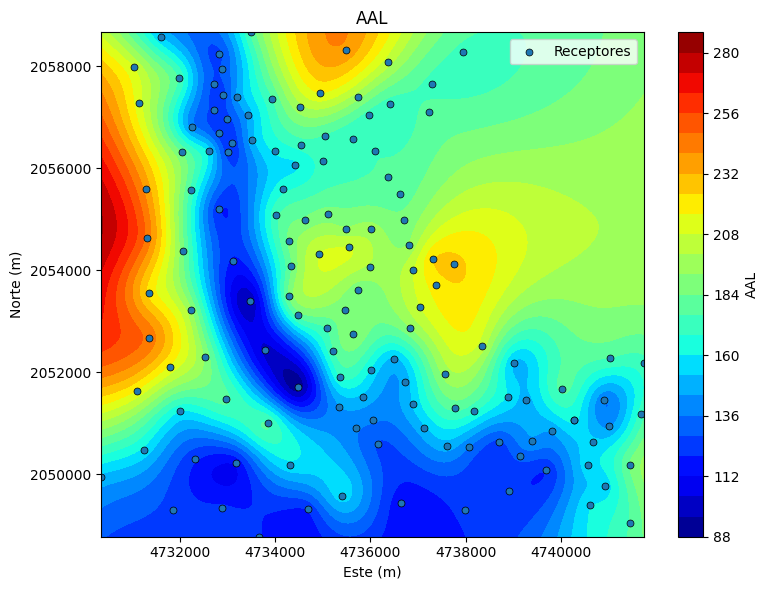

In [ ]:
from scipy.interpolate import griddata
from scipy.interpolate import RBFInterpolator

data = df[['X', 'Y', 'AAL']].dropna()

X = data['X'].to_numpy()
Y = data['Y'].to_numpy()
XY = data[['X', 'Y']].to_numpy()
AAL = data['AAL'].to_numpy()

nx, ny = 300, 300  # resolución (sube/baja según rendimiento)
xi = np.linspace(XY[:, 0].min(), XY[:, 0].max(), nx)
yi = np.linspace(XY[:, 1].min(), XY[:, 1].max(), ny)
Xi, Yi = np.meshgrid(xi, yi)
xg = np.column_stack([Xi.ravel(), Yi.ravel()])

# RBF Thin Plate Spline (muy “suave”, parecido a min-curv)
rbf = RBFInterpolator(XY, AAL, kernel="thin_plate_spline", smoothing=1.0)
Z = rbf(xg).reshape(ny, nx)

plt.figure(figsize=(8,6))
im = plt.contourf(Xi, Yi, Z, levels=30, cmap='jet')


plt.ticklabel_format(style='plain', axis='both')
plt.gca().xaxis.get_major_formatter().set_useOffset(False)
plt.gca().yaxis.get_major_formatter().set_useOffset(False)

plt.colorbar(im, label='AAL')
plt.scatter(df['X'], df['Y'], s=25, edgecolor='k', linewidth=0.5, label='Receptores')
plt.xlabel('Este (m)'); plt.ylabel('Norte (m)')
plt.title('AAL')
plt.legend()
plt.tight_layout()
plt.show()


### Calculo de la corrección y la anomalía de Bouguer Simple con $\rho_0$ con correlación mínima entre elevación y anomalia de Bouguer

In [ ]:
# Constantes
TWO_PI_G = 0.041916   # mGal/(m·g/cm^3)
rho0 = 2.67           # densidad inicial (g/cm^3) para el cálculo de la densidad de reducción por el método de Jung

# Referencia de altura promedio
h0 = float(df["Z"].mean())

#delta de h
dH = df["Z"] - h0

# Correccion de Bouguer Simple con rho0 y dH
CB_0 = TWO_PI_G * rho0 * dH

# Anomalía de aire libre
AAL = df['AAL']
# ABS (cuando ya tengamos la densidad de Jung en el paso 3): ABS = AAL - CB

# Anomalía deBouguer Simple con rho0 y dH
BA0 = AAL - CB_0

dH

,Z
0,-433.739897
1,-221.942897
2,-109.220897
3,-281.858897
4,-254.900897
...,...
131,103.586103
132,-221.642897
133,-228.307897
134,-404.101897


<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEgjzwk51y4c4WSsOwBV_PnP-drGecIAeRRlNS2kbXsvjuRFSfbTPOaMsOdD-Ns9U3jRneUKZacu9jrC2OpCO5jfxt9tPNQFiTdxR0nkfLJA7tiT1mWxtmJRCf6r-6r-MKm9pSdGX-UDeltY56YOQgs6QsWjAgtZmkOv0i4LCiPAARrG_c5eH6jvLr52rVBB" width="90%" style="max-width: 1000px;">
</div>

### Cálculo de la Densidad de Reducción por el método de Jung

In [ ]:
# Jung (centrado, usando dH = (h0 - h))
rho0 = 2.67

z = (dH - dH.mean()).to_numpy()
Bouguer_mean = (BA0 - BA0.mean()).to_numpy()
rho_jung = rho0 + np.sum(z*Bouguer_mean) / (TWO_PI_G * np.sum(z**2))

# En estos datos, por convención de signos, el valor puede salir con signo negativo.
# Nos quedamos con la magnitud física:
rho_final = abs(rho_jung)



print("Densidad de reducción (Jung):", rho_final)
df["rho_Jung"]   = rho_final

Densidad de reducción (Jung): 2.6300245002230516


<div align="center">
  <img src="https://blogger.googleusercontent.com/img/a/AVvXsEjGKLiW4HkV9JwnETeCNEO06kBuclqZFwe-o_iT3SR2_9zrqbayZRnkD9syUb44Y0hyAb_HdXivln6ZNJeMp9NhgrBwBTeDrQLwYpLpc0-UCgeFGwTr0M0PYN48We6MLytbFwqSyoqJCtjQMOCyW2aT-O_uuQTEsa_DZZLxV8gBgqxJS1KoGU4baGE0EdTR=s16000" width="90%" style="max-width: 1000px;">
</div>

### Calculo de la Correccion de Bouguer simple

In [ ]:
CB = TWO_PI_G * rho_final * df['Z']
df["CB"]    = CB
df

<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEjpXjOeN97ZTATaiVGiC9WtgDLKC_wR4GANpGBmfmAik6QnBqm3yvpADGsMP5m6yJ1W_kwhFXjd4Z9rsr35L8KrcXxv7A7GVrPNS-9fFt_uvDQ2xpQwz3O4zJYO_hByFjP9G2zzOiSeGSdONhFv08AgAAbv8lp7j4whPf7LqyCTk8Day5aURSyDYkItmCce" width="90%" style="max-width: 1000px;">
</div>

### Cálculo de la Anomalía de Bouguer Simple

In [ ]:
ABS = AAL - CB

df["dH_ref"]     = dH # (h0 - h)

df["ABS"]   = ABS


df


,Z
0,1802.569
1,2014.366
2,2127.088
3,1954.450
4,1981.408
...,...
131,2339.895
132,2014.666
133,2008.001
134,1832.207


<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEhcMwq326yaysXy1S_yX3a_GGaj2ltFefrU4x5f6S5923cdMeghijzfdg4r-z8pQV1Fiwj_h35OYAUTZbRYOTT5Uoy0UUzh3GDWpulwbxl3SunETvwxu_fFM7B_sV270twCGw-eKQH4dnrwBg2UHKx7GW8If9ly6euP4-eo4odmhMGiKWXmGWHUNa0Kmb8m" width="90%" style="max-width: 1000px;">
</div>

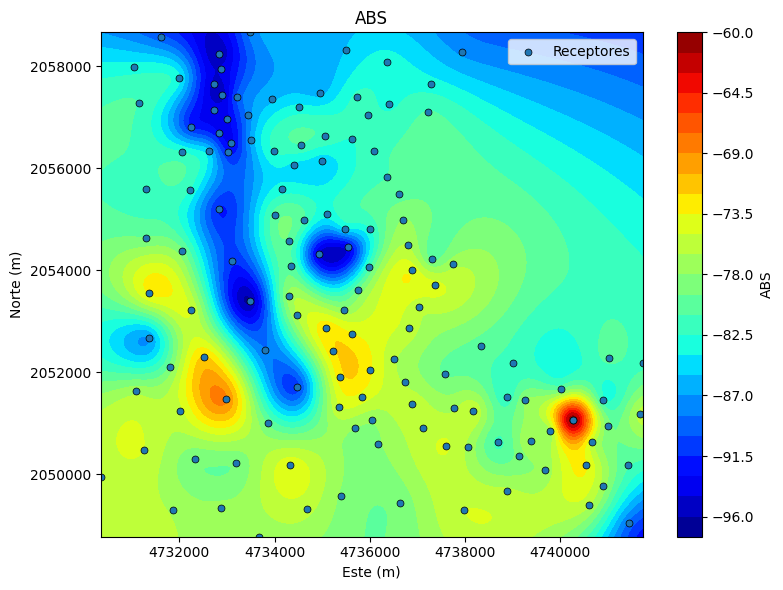

In [ ]:


data = df[['X', 'Y', 'ABS']].dropna()

X = data['X'].to_numpy()
Y = data['Y'].to_numpy()
XY = data[['X', 'Y']].to_numpy()
ABS = data['ABS'].to_numpy()

nx, ny = 300, 300  # resolución (sube/baja según rendimiento)
xi = np.linspace(XY[:, 0].min(), XY[:, 0].max(), nx)
yi = np.linspace(XY[:, 1].min(), XY[:, 1].max(), ny)
Xi, Yi = np.meshgrid(xi, yi)
xg = np.column_stack([Xi.ravel(), Yi.ravel()])

# RBF Thin Plate Spline (muy “suave”, parecido a min-curv)
rbf = RBFInterpolator(XY, ABS, kernel="thin_plate_spline", smoothing=1.0)
Z = rbf(xg).reshape(ny, nx)

plt.figure(figsize=(8,6))
im = plt.contourf(Xi, Yi, Z, levels=30, cmap='jet')


plt.ticklabel_format(style='plain', axis='both')
plt.gca().xaxis.get_major_formatter().set_useOffset(False)
plt.gca().yaxis.get_major_formatter().set_useOffset(False)

plt.colorbar(im, label='ABS')
plt.scatter(df['X'], df['Y'], s=25, edgecolor='k', linewidth=0.5, label='Receptores')
plt.xlabel('Este (m)'); plt.ylabel('Norte (m)')
plt.title('ABS')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import sys
print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Python executable: /usr/bin/python3


<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEiCda5nCE1l2i93CkZUc47XTKcskmhOhO0hb4OWoDGfiIiocqW_nTnsjHP4bhBRiiGPA45IrI3FE1pzaTz7FBj6j8bQ7_Mr-xCNioGtgmBdVsHa1z8OCw2ZIVWbuDuTR962ncu4pUzgoRlnFb3SPro_skQPXYLb7HErQ4ucloOz-R14FtDXV-s13NMkx-xs" width="90%" style="max-width: 1000px;">
</div>



# Correccion de Terreno

In [ ]:
import os
import numpy as np
import rioxarray as rioxr
import geopandas as gpd
import harmonica as hm

os.environ["GTIFF_SRS_SOURCE"] = "EPSG"

# Parámetros
PATH_DEM = "/content/dem_regional.tif"
rho = 2629.0       # kg/m3
radio = 50000.0    # m

# DEM
dem = rioxr.open_rasterio(PATH_DEM, masked=True).squeeze()
if "band" in dem.dims:
    dem = dem.isel(band=0)
dem = dem.astype("float32").sortby("x").sortby("y")
if dem.rio.nodata is not None:
    dem = dem.where(dem != dem.rio.nodata)
dem = dem.where(np.isfinite(dem) & (dem > 0))

# Estaciones al CRS del DEM
gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["Long"], df["Lat"]),
    crs="EPSG:4326"
).to_crs(dem.rio.crs)

xs = gdf.geometry.x.to_numpy()
ys = gdf.geometry.y.to_numpy()
zs = df["Z"].to_numpy(dtype=float)

def calc_ct(x0, y0, z0):
    sub = dem.sel(x=slice(x0-radio, x0+radio), y=slice(y0-radio, y0+radio))
    if sub.size == 0:
        return np.nan

    topo = sub.values.astype("float32")
    valid = np.isfinite(topo) & (topo > 0)
    if not valid.any():
        return np.nan

    topo = np.where(valid, topo, np.nan)
    dens = np.where(valid, rho, np.nan).astype("float32")
    xg, yg = sub.x.values, sub.y.values

    topo_layer = hm.prism_layer(
        coordinates=(xg, yg),
        surface=topo,
        reference=0.0,
        properties={"density": dens},
    )
    slab_layer = hm.prism_layer(
        coordinates=(xg, yg),
        surface=np.where(valid, z0, np.nan).astype("float32"),
        reference=0.0,
        properties={"density": dens},
    )

    gz_topo = topo_layer.prism_layer.gravity(
        coordinates=(np.array([x0]), np.array([y0]), np.array([z0])),
        field="g_z",
        progressbar=False,
    )[0]

    gz_slab = slab_layer.prism_layer.gravity(
        coordinates=(np.array([x0]), np.array([y0]), np.array([z0])),
        field="g_z",
        progressbar=False,
    )[0]

    return abs(gz_topo - gz_slab)

df["CT"] = [calc_ct(x0, y0, z0) for x0, y0, z0 in zip(xs, ys, zs)]
df

,Station,Long,Lat,X,Y,Z,G_Obs,Mask,GRS1980_(gt),CA,AAL,rho_Jung,dH_ref,CB,ABS,CT
0,93,-75.4080,4.4427,4732883.463,2049345.170,1802.569,977628.5013,18.5238,978063.682117,-556.272793,121.091976,2.630025,-433.739897,198.715399,-77.623423,18.380031
1,98,-75.3415,4.4585,4740260.711,2051069.569,2014.366,977621.7091,14.8273,978063.902439,-621.633348,179.440009,2.630025,-221.942897,222.063923,-42.623914,15.133291
2,1000,-75.4053,4.5156,4733205.458,2057405.449,2127.088,977552.7659,17.8755,978064.705131,-656.419357,144.480125,2.630025,-109.220897,234.490409,-90.010283,18.648457
3,1001,-75.4063,4.5073,4733091.517,2056492.891,1954.450,977583.5755,25.0323,978064.587823,-603.143270,122.130947,2.630025,-281.858897,215.458777,-93.327830,26.424829
4,1002,-75.4071,4.5116,4733001.529,2056965.559,1981.408,977578.0543,23.3035,978064.648571,-611.462509,124.868238,2.630025,-254.900897,218.430630,-93.562392,23.299548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,3023,-75.3437,4.4639,4740019.008,2051673.049,2339.895,977519.8658,17.0514,978063.977916,-722.091597,177.979481,2.630025,103.586103,257.950275,-79.970794,16.459775
132,3024,-75.3415,4.4585,4740260.711,2051069.569,2014.666,977585.9545,14.8246,978063.902439,-621.725928,143.777989,2.630025,-221.642897,222.096995,-78.319006,15.107289
133,3025,-75.3457,4.4563,4739795.423,2050836.891,2008.001,977588.4678,13.8327,978063.871714,-619.669109,144.265194,2.630025,-228.307897,221.362245,-77.097051,14.732078
134,73124018,-75.4172,4.4422,4731859.783,2049294.485,1832.207,977623.5576,19.2228,978063.675158,-565.419080,125.301522,2.630025,-404.101897,201.982696,-76.681173,19.091318


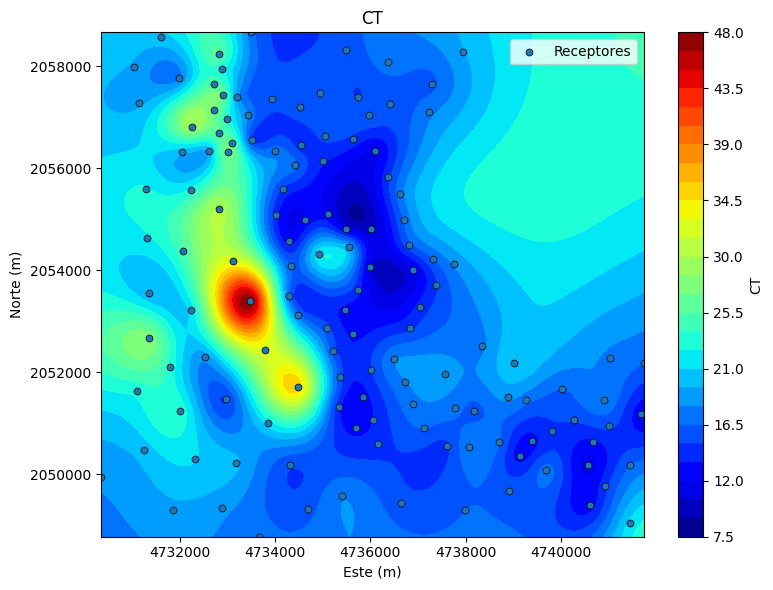

In [ ]:
from scipy.interpolate import griddata
from scipy.interpolate import RBFInterpolator

data = df[['X', 'Y', 'CT']].dropna()

X = data['X'].to_numpy()
Y = data['Y'].to_numpy()
XY = data[['X', 'Y']].to_numpy()
CT = data['CT'].to_numpy()

nx, ny = 300, 300  # resolución (sube/baja según rendimiento)
xi = np.linspace(XY[:, 0].min(), XY[:, 0].max(), nx)
yi = np.linspace(XY[:, 1].min(), XY[:, 1].max(), ny)
Xi, Yi = np.meshgrid(xi, yi)
xg = np.column_stack([Xi.ravel(), Yi.ravel()])

# RBF Thin Plate Spline (muy “suave”, parecido a min-curv)
rbf = RBFInterpolator(XY, CT, kernel="thin_plate_spline", smoothing=1.0)
Z = rbf(xg).reshape(ny, nx)

plt.figure(figsize=(8,6))
im = plt.contourf(Xi, Yi, Z, levels=30, cmap='jet')


plt.ticklabel_format(style='plain', axis='both')
plt.gca().xaxis.get_major_formatter().set_useOffset(False)
plt.gca().yaxis.get_major_formatter().set_useOffset(False)

plt.colorbar(im, label='CT')
plt.scatter(df['X'], df['Y'], s=25, edgecolor='k', linewidth=0.5, label='Receptores')
plt.xlabel('Este (m)'); plt.ylabel('Norte (m)')
plt.title('CT')
plt.legend()
plt.tight_layout()
plt.show()

<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEifW1F6UfaRRz7REDDeQLUz2QZn_d9FSvfTbtBMxB9i73xIH_T7dcmGfFw5ySOkLJqw3CD2sipkgNLZEYORvL0ywf93bVNoCFsUPKCKB5UZjL4IRcvVtKa99BrrtqvuqpUEpJ_4ie-liDB3Z_NjGCnpRf2La0i4lQuawT87B00sQIMicLsfgoT8Vs4C2xl3" width="90%" style="max-width: 1000px;">
</div>



### Cálculo de la Anomalía de Bouguer Total


In [ ]:
df['ABT'] = df['G_Obs'] - df['CA'] - df['GRS1980_(gt)'] + df['CT'] - df['CB']
df

,Station,Long,Lat,X,Y,Z,G_Obs,Mask,GRS1980_(gt),CA,AAL,rho_Jung,dH_ref,CB,ABS,CT,ABT
0,93,-75.4080,4.4427,4732883.463,2049345.170,1802.569,977628.5013,18.5238,978063.682117,-556.272793,121.091976,2.630025,-433.739897,198.715399,-77.623423,18.380031,-59.243393
1,98,-75.3415,4.4585,4740260.711,2051069.569,2014.366,977621.7091,14.8273,978063.902439,-621.633348,179.440009,2.630025,-221.942897,222.063923,-42.623914,15.133291,-27.490624
2,1000,-75.4053,4.5156,4733205.458,2057405.449,2127.088,977552.7659,17.8755,978064.705131,-656.419357,144.480125,2.630025,-109.220897,234.490409,-90.010283,18.648457,-71.361826
3,1001,-75.4063,4.5073,4733091.517,2056492.891,1954.450,977583.5755,25.0323,978064.587823,-603.143270,122.130947,2.630025,-281.858897,215.458777,-93.327830,26.424829,-66.903002
4,1002,-75.4071,4.5116,4733001.529,2056965.559,1981.408,977578.0543,23.3035,978064.648571,-611.462509,124.868238,2.630025,-254.900897,218.430630,-93.562392,23.299548,-70.262843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,3023,-75.3437,4.4639,4740019.008,2051673.049,2339.895,977519.8658,17.0514,978063.977916,-722.091597,177.979481,2.630025,103.586103,257.950275,-79.970794,16.459775,-63.511019
132,3024,-75.3415,4.4585,4740260.711,2051069.569,2014.666,977585.9545,14.8246,978063.902439,-621.725928,143.777989,2.630025,-221.642897,222.096995,-78.319006,15.107289,-63.211718
133,3025,-75.3457,4.4563,4739795.423,2050836.891,2008.001,977588.4678,13.8327,978063.871714,-619.669109,144.265194,2.630025,-228.307897,221.362245,-77.097051,14.732078,-62.364973
134,73124018,-75.4172,4.4422,4731859.783,2049294.485,1832.207,977623.5576,19.2228,978063.675158,-565.419080,125.301522,2.630025,-404.101897,201.982696,-76.681173,19.091318,-57.589855


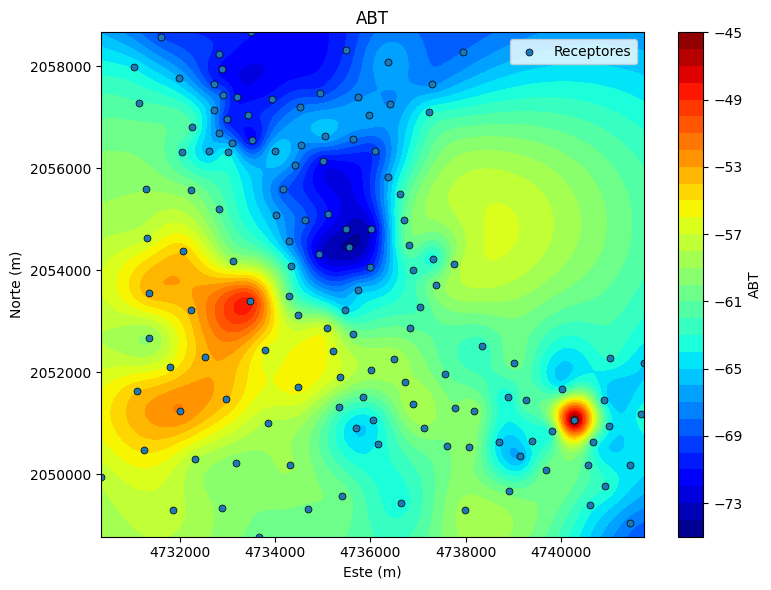

In [ ]:
from scipy.interpolate import griddata
from scipy.interpolate import RBFInterpolator

data = df[['X', 'Y', 'ABT']].dropna()

X = data['X'].to_numpy()
Y = data['Y'].to_numpy()
XY = data[['X', 'Y']].to_numpy()
ABT = data['ABT'].to_numpy()

nx, ny = 300, 300  # resolución (sube/baja según rendimiento)
xi = np.linspace(XY[:, 0].min(), XY[:, 0].max(), nx)
yi = np.linspace(XY[:, 1].min(), XY[:, 1].max(), ny)
Xi, Yi = np.meshgrid(xi, yi)
xg = np.column_stack([Xi.ravel(), Yi.ravel()])

rbf = RBFInterpolator(XY, ABT, kernel="thin_plate_spline", smoothing=1.0)
Z = rbf(xg).reshape(ny, nx)

plt.figure(figsize=(8,6))
im = plt.contourf(Xi, Yi, Z, levels=30, cmap='jet')


plt.ticklabel_format(style='plain', axis='both')
plt.gca().xaxis.get_major_formatter().set_useOffset(False)
plt.gca().yaxis.get_major_formatter().set_useOffset(False)

plt.colorbar(im, label='ABT')
plt.scatter(df['X'], df['Y'], s=25, edgecolor='k', linewidth=0.5, label='Receptores')
plt.xlabel('Este (m)'); plt.ylabel('Norte (m)')
plt.title('ABT')
plt.legend()
plt.tight_layout()
plt.show()

<div align="center">
<img src="https://blogger.googleusercontent.com/img/a/AVvXsEgDcBxIUAOr8yj4wfanidUU_Va7vg9VGDw8otvgW88B6uEmvNXZtPuTZXZWQI7302-j-U1RFMEc53PGYxo5F3F0tsXVldmVclnNw409YapzrhpmVo9zLGVVl11pnkroBAE9e5WRbfyAIrshYZ7k99Wpr5am9V5dDpM89Ihs9Soot2e_0uz2NFg_JB5wuhcT" width="90%" style="max-width: 1000px;">
</div>

### Cálculo de la Anomalía Residual de Bouguer

In [ ]:
X = df.X
Y = df.Y
ABT = df["ABT"]
coords = np.column_stack((X, Y))

In [ ]:
# df = df.drop(index=1).reset_index(drop=True)

coords = np.column_stack((df.X, df.Y))
ABT = df["ABT"]

poly = PolynomialFeatures(degree=2)
coords_poly = poly.fit_transform(coords)

model = LinearRegression().fit(coords_poly, ABT)
regional = model.predict(coords_poly)
df["ARes"] = ABT - regional



In [ ]:
df

,Station,Long,Lat,X,Y,Z,G_Obs,Mask,GRS1980_(gt),CA,AAL,rho_Jung,dH_ref,CB,ABS,CT,ABT,ARes
0,93,-75.4080,4.4427,4732883.463,2049345.170,1802.569,977628.5013,18.5238,978063.682117,-556.272793,121.091976,2.630025,-433.739897,198.715399,-77.623423,18.380031,-59.243393,-2.133960
1,98,-75.3415,4.4585,4740260.711,2051069.569,2014.366,977621.7091,14.8273,978063.902439,-621.633348,179.440009,2.630025,-221.942897,222.063923,-42.623914,15.133291,-27.490624,33.854547
2,1000,-75.4053,4.5156,4733205.458,2057405.449,2127.088,977552.7659,17.8755,978064.705131,-656.419357,144.480125,2.630025,-109.220897,234.490409,-90.010283,18.648457,-71.361826,-3.345810
3,1001,-75.4063,4.5073,4733091.517,2056492.891,1954.450,977583.5755,25.0323,978064.587823,-603.143270,122.130947,2.630025,-281.858897,215.458777,-93.327830,26.424829,-66.903002,-1.427886
4,1002,-75.4071,4.5116,4733001.529,2056965.559,1981.408,977578.0543,23.3035,978064.648571,-611.462509,124.868238,2.630025,-254.900897,218.430630,-93.562392,23.299548,-70.262843,-3.651677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,3023,-75.3437,4.4639,4740019.008,2051673.049,2339.895,977519.8658,17.0514,978063.977916,-722.091597,177.979481,2.630025,103.586103,257.950275,-79.970794,16.459775,-63.511019,-2.162849
132,3024,-75.3415,4.4585,4740260.711,2051069.569,2014.666,977585.9545,14.8246,978063.902439,-621.725928,143.777989,2.630025,-221.642897,222.096995,-78.319006,15.107289,-63.211718,-1.866547
133,3025,-75.3457,4.4563,4739795.423,2050836.891,2008.001,977588.4678,13.8327,978063.871714,-619.669109,144.265194,2.630025,-228.307897,221.362245,-77.097051,14.732078,-62.364973,-0.734996
134,73124018,-75.4172,4.4422,4731859.783,2049294.485,1832.207,977623.5576,19.2228,978063.675158,-565.419080,125.301522,2.630025,-404.101897,201.982696,-76.681173,19.091318,-57.589855,-2.464685


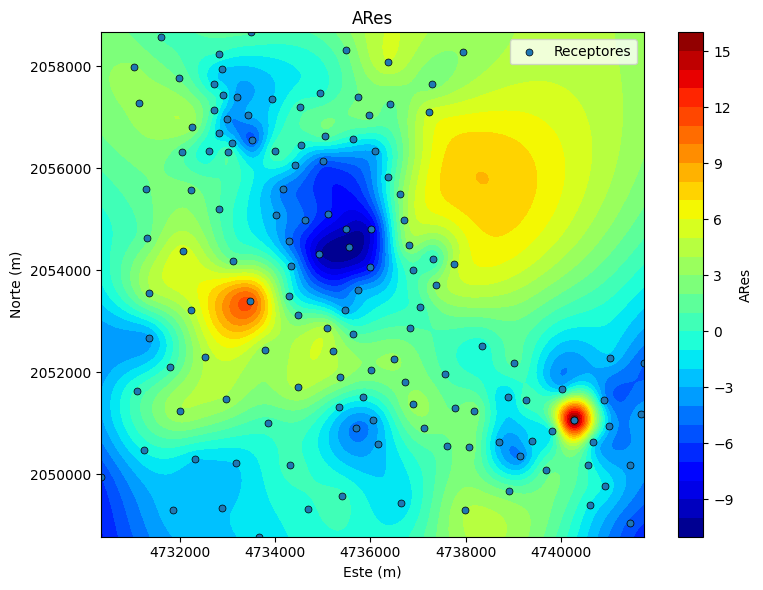

In [ ]:
from scipy.interpolate import griddata
from scipy.interpolate import RBFInterpolator

data = df[['X', 'Y', 'ARes']].dropna()

X = data['X'].to_numpy()
Y = data['Y'].to_numpy()
XY = data[['X', 'Y']].to_numpy()
ARes = data['ARes'].to_numpy()

nx, ny = 300, 300  # resolución (sube/baja según rendimiento)
xi = np.linspace(XY[:, 0].min(), XY[:, 0].max(), nx)
yi = np.linspace(XY[:, 1].min(), XY[:, 1].max(), ny)
Xi, Yi = np.meshgrid(xi, yi)
xg = np.column_stack([Xi.ravel(), Yi.ravel()])

# RBF Thin Plate Spline (muy “suave”, parecido a min-curv)
rbf = RBFInterpolator(XY, ARes, kernel="thin_plate_spline", smoothing=1.0)
Z = rbf(xg).reshape(ny, nx)

plt.figure(figsize=(8,6))
im = plt.contourf(Xi, Yi, Z, levels=30, cmap='jet')


plt.ticklabel_format(style='plain', axis='both')
plt.gca().xaxis.get_major_formatter().set_useOffset(False)
plt.gca().yaxis.get_major_formatter().set_useOffset(False)

plt.colorbar(im, label='ARes')
plt.scatter(df['X'], df['Y'], s=25, edgecolor='k', linewidth=0.5, label='Receptores')
plt.xlabel('Este (m)'); plt.ylabel('Norte (m)')
plt.title('ARes')
plt.legend()
plt.tight_layout()
plt.show()



<img src="https://blogger.googleusercontent.com/img/a/AVvXsEgRwEsdxs5LpBehJtfHIHt1pr5LKHKGOCkLhujxTw_ZRZTaNkZZue0wgKUL_eAQ7gs9cFGP7mKpk3zTZux5Ips87Sx5U15Sd33KhSiGrxEVSTJ036Mvs9ohCeIyu9VDC48gRONA36IzywgLxYT0PHIx2wp7-MTCyCXAZAFVdlTiyODJT3WitDC12m_0hgnO
" width="80%" style="max-width: 10000px;">


In [ ]:
df

,Station,Long,Lat,X,Y,Z,G_Obs,Mask,GRS1980_(gt),CA,AAL,rho_Jung,dH_ref,CB,ABS,CT,ABT,ARes
0,93,-75.4080,4.4427,4732883.463,2049345.170,1802.569,977628.5013,18.5238,978063.682117,-556.272793,121.091976,2.630025,-433.739897,198.715399,-77.623423,18.380031,-59.243393,-2.133960
1,98,-75.3415,4.4585,4740260.711,2051069.569,2014.366,977621.7091,14.8273,978063.902439,-621.633348,179.440009,2.630025,-221.942897,222.063923,-42.623914,15.133291,-27.490624,33.854547
2,1000,-75.4053,4.5156,4733205.458,2057405.449,2127.088,977552.7659,17.8755,978064.705131,-656.419357,144.480125,2.630025,-109.220897,234.490409,-90.010283,18.648457,-71.361826,-3.345810
3,1001,-75.4063,4.5073,4733091.517,2056492.891,1954.450,977583.5755,25.0323,978064.587823,-603.143270,122.130947,2.630025,-281.858897,215.458777,-93.327830,26.424829,-66.903002,-1.427886
4,1002,-75.4071,4.5116,4733001.529,2056965.559,1981.408,977578.0543,23.3035,978064.648571,-611.462509,124.868238,2.630025,-254.900897,218.430630,-93.562392,23.299548,-70.262843,-3.651677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,3023,-75.3437,4.4639,4740019.008,2051673.049,2339.895,977519.8658,17.0514,978063.977916,-722.091597,177.979481,2.630025,103.586103,257.950275,-79.970794,16.459775,-63.511019,-2.162849
132,3024,-75.3415,4.4585,4740260.711,2051069.569,2014.666,977585.9545,14.8246,978063.902439,-621.725928,143.777989,2.630025,-221.642897,222.096995,-78.319006,15.107289,-63.211718,-1.866547
133,3025,-75.3457,4.4563,4739795.423,2050836.891,2008.001,977588.4678,13.8327,978063.871714,-619.669109,144.265194,2.630025,-228.307897,221.362245,-77.097051,14.732078,-62.364973,-0.734996
134,73124018,-75.4172,4.4422,4731859.783,2049294.485,1832.207,977623.5576,19.2228,978063.675158,-565.419080,125.301522,2.630025,-404.101897,201.982696,-76.681173,19.091318,-57.589855,-2.464685


# Guardar archivo final

In [ ]:
# Exportar el DataFrame a un archivo CSV
output_filename = 'Resultados_Gravimetria_Python.csv'
df.to_csv(output_filename, sep=';', index=False)
print(f"Archivo guardado como: {output_filename}")

Archivo guardado como: Resultados_Gravimetria_Python.csv
